# Probe Guidance: Predictor Testing and Analysis

In [1]:
import sys
sys.path.insert(0, "/home/jack/code/vjepa2-probe-guidance/vjepa2")
print(sys.path)

['/home/jack/code/vjepa2-probe-guidance/vjepa2', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages', '/home/jack/code/vjepa2-probe-guidance/vjepa2/src', '/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages/rerun_sdk']


In [2]:
from pathlib import Path
import copy
import os

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
from torch.nn import functional as F
import torchvision.transforms as T
from scipy.spatial.transform import Rotation
from tqdm import tqdm

In [3]:
from app.vjepa_ll_probe_guidance.ll_probe_guidance import LLProbeGuidanceDataset, standardize_actions, standardize_states
from app.vjepa_ll_probe_guidance.utils import init_video_model
from app.vjepa_ll_probe_guidance.transforms import make_transforms

/home/jack/code/vjepa2-probe-guidance/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [4]:
encoder, predictor = init_video_model(
        device="cuda:0",
        patch_size=16,
        max_num_frames=512,
        tubelet_size=2,
        model_name="vit_large",
        crop_size=256,
        pred_depth=12,
        pred_num_heads=12,
        pred_embed_dim=768,
        action_embed_dim=6,
        predictor_type="ac",
        pred_is_frame_causal=True,
        use_extrinsics=False,
        use_sdpa=True,
        use_rope=True
    )
target_encoder = copy.deepcopy(encoder)

encoder.eval()
predictor.eval()
target_encoder.eval()

def load_state_dict_with_ddp_fix(model, state_dict):
    new_state_dict = {}
    for k, v in state_dict.items():
        # Remove 'module.' prefix if it exists
        new_key = k.replace("module.", "")
        new_state_dict[new_key] = v

    model.load_state_dict(new_state_dict, strict=True)
    return model

resume_path = os.path.join("/home/jack/code/vjepa2-probe-guidance/vjepa2/outputs/ll_probe_guidance_vitl_4", "best.pt")
if os.path.exists(resume_path):
    print(f"Loading checkpoint from {resume_path}")
    checkpoint = torch.load(resume_path, map_location=torch.device("cpu"))
    encoder = load_state_dict_with_ddp_fix(encoder, checkpoint["encoder"])
    predictor = load_state_dict_with_ddp_fix(predictor, checkpoint["predictor"])
    target_encoder = load_state_dict_with_ddp_fix(target_encoder, checkpoint["target_encoder"])
else:
    print(f"Checkpoint not found at {resume_path}")

print("=" * 20 + "PREDICTOR" + "=" * 20)
print(predictor)
print("=" * 20 + "TARGET ENCODER" + "=" * 20)
print(target_encoder)

Loading checkpoint from /home/jack/code/vjepa2-probe-guidance/vjepa2/outputs/ll_probe_guidance_vitl_4/best.pt
====================PREDICTOR====================
VisionTransformerPredictorAC(
  (predictor_embed): Linear(in_features=1024, out_features=768, bias=True)
  (action_encoder): Linear(in_features=6, out_features=768, bias=True)
  (state_encoder): Linear(in_features=6, out_features=768, bias=True)
  (extrinsics_encoder): Linear(in_features=5, out_features=768, bias=True)
  (predictor_blocks): ModuleList(
    (0-11): 12 x ACBlock(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
      (attn): ACRoPEAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, b

## Dataset Initialization and Exploration

In [5]:
crop_size = 256
tokens_per_frame = int((crop_size // encoder.patch_size) ** 2)
transform = make_transforms(
    crop_size=crop_size,
)

# SET THIS TO THE NUMBER OF FRAMES YOU WANT IN A CLIP
T = 8

dataset = LLProbeGuidanceDataset(
    data_root="/home/jack/data/probe_guidance_dataset_june/test",
    frames_per_clip=T,
    frame_skip=1,
    frames_per_second=4,
    transform=transform,
    is_train=False,
)

loader = torch.utils.data.DataLoader(
    dataset,
    shuffle=False,
    batch_size=1,
    drop_last=True,
    pin_memory=False,
    num_workers=8,
)

Scanning 7 episodes for valid tracking clips...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 37.85it/s]

Retained 7 episodes.


In [6]:
def load_clips(sample):
    clips = sample[0].to("cuda:0", non_blocking=True)  # [B C T H W]
    actions = sample[1]  # [B T-1 6]
    states = sample[2]  # [B T 6]
    extrinsics = sample[3].to("cuda:0", dtype=torch.float, non_blocking=True)  # [B T 6]
    return (clips, actions, states, extrinsics)

sample = next(iter(loader))
clips, actions, states, _ = load_clips(sample)
clips = clips[:, :, :T]
actions = actions[:, :T-1]
states = states[:, :T]
print(f"clips: {clips.shape}; states: {states.shape}; actions: {actions.shape}")

clips: torch.Size([1, 3, 8, 256, 256]); states: torch.Size([1, 8, 6]); actions: torch.Size([1, 7, 6])


### Clip Visualization

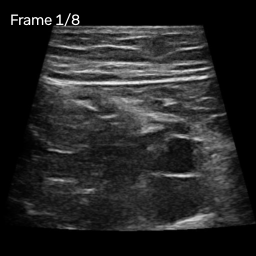

In [7]:
import io
import cv2
import imageio
import numpy as np
import torch
from IPython.display import Image, display

clip = clips[0] if clips.dim() == 5 else clips

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1, 1).to(clip.device)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1, 1).to(clip.device)

clip_unnorm = (clip * std) + mean
frames = clip_unnorm.permute(1, 2, 3, 0)

frames_uint8 = (
    (frames * 255).clamp(0, 255).detach().cpu().numpy().astype(np.uint8)
)

T = frames_uint8.shape[0]
frames_with_text = []

for idx in range(T):
    frame = frames_uint8[idx].copy()
    text = f"Frame {idx + 1}/{T}"

    cv2.putText(
        frame,
        text,
        (10, 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 255),
        1,
        cv2.LINE_AA,
    )

    frames_with_text.append(frame)

buf = io.BytesIO()
imageio.mimsave(buf, frames_with_text, format="GIF", fps=4, loop=0)
display(Image(data=buf.getvalue()))

### Clip Descriptive Statistics

In [18]:
print(f"{actions.shape=}")
act_data = actions.squeeze(0).cpu().numpy()
print(f"{act_data.shape=}")
d_trans = act_data[:, :3]
d_rpy = act_data[:, 3:]

step_distances = np.linalg.norm(d_trans, axis=-1)
total_path_distance = np.sum(step_distances)

delta_rots = Rotation.from_euler('xyz', d_rpy, degrees=True)
step_rot_angles_rad = np.linalg.norm(delta_rots.as_rotvec(), axis=-1)
total_angular_distance_deg = np.degrees(np.sum(step_rot_angles_rad))

current_rot = Rotation.identity()
current_pos = np.zeros(3)

for i in range(len(act_data)):
    current_pos += current_rot.apply(d_trans[i])
    current_rot = current_rot * delta_rots[i]

net_displacement = np.linalg.norm(current_pos)
net_rotation_angle_deg = np.degrees(np.linalg.norm(current_rot.as_rotvec()))

print(f"Total Translation Path: {total_path_distance:.6f} meters")
print(f"Total Angular Motion:   {total_angular_distance_deg:.2f}°")
print(f"Net Translation Shift:  {net_displacement:.6f} meters")
print(f"Net Angular Shift:      {net_rotation_angle_deg:.2f}°")

# Straightness index
straightness_index = net_displacement / total_path_distance

# Translational Jerk
accel = np.diff(d_trans, axis=0)
jerk = np.diff(accel, axis=0)
mean_jerk_magnitude = np.mean(np.linalg.norm(jerk, axis=-1))

# Directional coherence
norms = np.linalg.norm(d_trans, axis=-1, keepdims=True)
normalized_steps = d_trans / (norms + 1e-8)  # avoid div by 0
cosine_sims = np.sum(normalized_steps[:-1] * normalized_steps[1:], axis=-1)
mean_directional_coherence = np.mean(cosine_sims)

# Angular jerk
rot_vecs = delta_rots.as_rotvec()  # axis-angle vectors
angular_jerk = np.diff(np.diff(rot_vecs, axis=0), axis=0)
mean_angular_jerk = np.mean(np.linalg.norm(angular_jerk, axis=-1))

print("-" * 20)
print(f"Straightness Index:       {straightness_index:.4f}  (1.0 = perfect straight line)")
print(f"Directional Coherence:    {mean_directional_coherence:.4f}  (1.0 = smooth vector flow)")
print(f"Mean Linear Delta Jerk:   {mean_jerk_magnitude:.6f}")
print(f"Mean Angular Delta Jerk:  {np.degrees(mean_angular_jerk):.2f}°")

actions.shape=torch.Size([1, 7, 6])
act_data.shape=(7, 6)
Total Translation Path: 0.053945 meters
Total Angular Motion:   18.74°
Net Translation Shift:  0.007697 meters
Net Angular Shift:      6.94°
--------------------
Straightness Index:       0.1427  (1.0 = perfect straight line)
Directional Coherence:    0.3877  (1.0 = smooth vector flow)
Mean Linear Delta Jerk:   0.008286
Mean Angular Delta Jerk:  3.02°


## Performance Analyses

In [9]:
def forward_target(c, normalize_reps=True):
    B, C, T, H, W = c.size()
    c = c.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
    h = encoder(c)
    h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)
    if normalize_reps:
        h = F.layer_norm(h, (h.size(-1),))
    return h

def step_predictor(z, a, s, normalize_reps=True):
    standardized_actions = standardize_actions(a).to("cuda:0", dtype=torch.float, non_blocking=True)
    standardized_states = standardize_states(s).to("cuda:0", dtype=torch.float, non_blocking=True)
    z = predictor(z, standardized_actions, standardized_states)[:, -tokens_per_frame:]
    if normalize_reps:
        z = F.layer_norm(z, (z.size(-1),))
    return z

def loss_fn(z, h):
    # NOTE: The caller is now responsible for making sure that the tokens in z and h align.
    # TODO: MAKE SURE THIS IS UPDATED IN ENERGY LANDSCAPE SECTION AND BEYOND (world model section)
    loss = torch.abs(z - h)  # [B, N, D]
    loss = torch.mean(loss, dim=[1, 2])
    return loss.tolist()

### Rollout Length Analysis

A natural question to have about the JEPA predictor/world model is how does it handle rollouts over a progressively longer horizon. In other words, can the predictor reliably determine the correct state of the world 1 step ahead? 2 steps ahead? 3 steps ahead? etc. Or does its predictions of the future states steadily (or quickly) degrade? Assuming degradation happens as rollouts occur over longer horizons, what does the degradation look like? Does it degrade linearly? Exponentially? Randomly? Is this degradation pattern consistent across samples within a dataset? Is it consistent across datasets? We are currently confined to the ultrasound dataset in this case, but it would be interesting to analyze degradation patterns across datasets. Do datasets exhibit different degradation patterns? or is degradation consistent across datasets? In either case, it would be interesting to explore why.

/usr/lib/python3.10/contextlib.py:103: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


loss_total=[0.44932305812835693]
z_rollout_cur.shape=torch.Size([1, 2048, 1024])
h_rollout.shape=torch.Size([1, 2048, 1024])


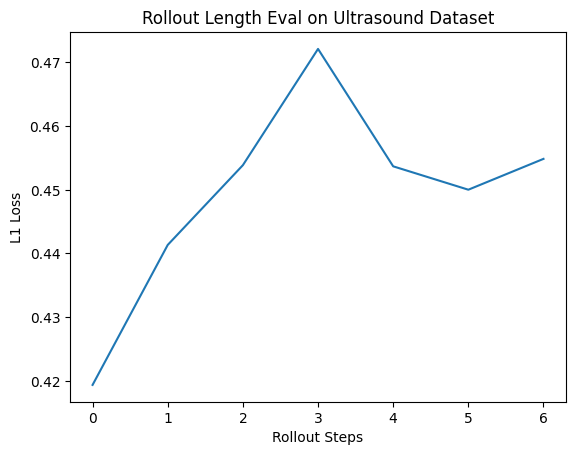

In [10]:
with torch.no_grad():
    h_rollout = forward_target(clips)
    
    # start with the representation of the first frame from the encoder
    z_rollout_cur = h_rollout[:, :tokens_per_frame]
    
    rollout_steps = T-1
    for n in range(rollout_steps):
        a_cur, s_cur, = actions[:, :n+1], states[:, :n+1]
        z_rollout_next = step_predictor(z_rollout_cur, a_cur, s_cur)[:, -tokens_per_frame:]
        z_rollout_cur = torch.cat([z_rollout_cur, z_rollout_next], dim=1)

loss_total = loss_fn(z_rollout_cur[:, tokens_per_frame:], h_rollout[:, tokens_per_frame:])
print(f"{loss_total=}")

print(f"{z_rollout_cur.shape=}")
print(f"{h_rollout.shape=}")

# Calculate L1 loss for each frame
frame_losses = []
for n in range(T):
    pred_frame = z_rollout_cur[:, tokens_per_frame * n:tokens_per_frame * (n+1)]
    gt_frame = h_rollout[:, tokens_per_frame * n:tokens_per_frame * (n+1)]
    cur_frame_loss = loss_fn(pred_frame, gt_frame)
    frame_losses.append(cur_frame_loss)
    #print(f"frame {n+1} loss: {cur_frame_loss} - {pred_frame.shape=} - {gt_frame.shape=}")

plt.plot(frame_losses[1:])

plt.title("Rollout Length Eval on Ultrasound Dataset")
plt.xlabel("Rollout Steps")
plt.ylabel("L1 Loss")

plt.show()

### Energy Landscape Analysis

The gist of this analysis approach is to create a "grid" of actions (like a grid search almost), and then figure out how good each action on the grid does. Good as in does it make the L1 loss between the output of the predictor and the ground truth output from the target encoder lower? Some questions that I have:
- What exactly is energy in this context? Why is it framed this way?
- How useful is this from an analysis perspective? Can it provide valuable insights into model performance?
- What is the right way to interpret an energy landscape?
- Can you extend this idea to the dataset level? Instead of just the sample level?

In [11]:
# NOTE: the actions are in the probe's coordinate frame, while the states are 
# in the camera's coordinate frame. Does this have a negative impact on the model?
# Nonetheless, computing the new pose needs to account for this discrepancy.

# NOTE: state and action may be standardized, may need to account for this or rethink dataset/dataloader
# to not do standardization. Perhaps standardization should happen in training/testing and before passing to model
# forward functions (or within the forward functions themselves). doing it in dataset makes it hard to do visualizations.
# breaking standardization out can be good from a single-responsibility principle standpoint.

def compute_new_pose(pose, action):
    """
    :param pose: [B, T=1, 6] (x, y, z, rx, ry, rz in Euler angles) in camera frame
    :param action: [B, T=1, 6] (dx, dy, dz, drx, dry, drz) in local object frame
    :returns: [B, T=1, 6] updated pose in camera frame
    """
    device, dtype = pose.device, pose.dtype
    
    pose_np = pose[:, 0].detach().cpu().numpy()
    action_np = action[:, 0].detach().cpu().numpy()

    R_pose = Rotation.from_euler("xyz", pose_np[:, 3:6], degrees=True)
    R_pose_mat = R_pose.as_matrix()  # [B, 3, 3]

    # local action translation: [B, 3, 1] column vector
    local_dxyz = action_np[:, :3, None]
    
    global_dxyz = (R_pose_mat @ local_dxyz).squeeze(-1)  # [B, 3]
    new_xyz = pose_np[:, :3] + global_dxyz

    R_action = Rotation.from_euler("xyz", action_np[:, 3:6], degrees=True)
    R_new = R_pose * R_action

    new_angle = R_new.as_euler("xyz", degrees=True)  # [B, 3]

    new_pose = np.concatenate([new_xyz, new_angle], axis=-1)

    # Restore dimensions to [B, T=1, 6]
    return torch.from_numpy(new_pose).to(device=device, dtype=dtype)[:, None]

In [12]:
def forward_action_grid(z, nsamples, grid_size=0.075, normalize_reps=True, action_repeat=1):

    def make_action_grid(grid_size=grid_size):
        action_samples = []
        for da in np.linspace(-grid_size, grid_size, nsamples):
            for db in np.linspace(-grid_size, grid_size, nsamples):
                for dc in np.linspace(-grid_size, grid_size, nsamples):
                    action_samples += [torch.tensor([da, db, dc, 0, 0, 0], device="cpu", dtype=z.dtype)]
        return torch.stack(action_samples, dim=0).unsqueeze(1)

    # Sample grid of actions
    action_samples = make_action_grid()
    print(f"Sampled grid of actions; num actions = {len(action_samples)}")

    # Context frame rep and context pose
    # NOTE: only uses the first frame/state
    z_hat = z[:, :tokens_per_frame].repeat(int(nsamples**3), 1, 1)  # [S, N, D] <- NOTE: N = tokens per frame??
    s_hat = states[:, :1].repeat((int(nsamples**3), 1, 1))  # [S, 1, 7]
    a_hat = action_samples  # [S, 1, 6]

    for _ in range(action_repeat):
        _z = step_predictor(z_hat, a_hat, s_hat)
        _s = compute_new_pose(s_hat[:, -1:], a_hat[:, -1:])
        z_hat = torch.cat([z_hat, _z], dim=1)
        s_hat = torch.cat([s_hat, _s], dim=1)
        a_hat = torch.cat([a_hat, action_samples], dim=1)

    # print(f"z hat shape: {z_hat.shape}")
    # print(f"s hat shape: {s_hat.shape}")
    # print(f"a hat shape: {a_hat.shape}")
    return z_hat, s_hat, a_hat

In [13]:
# Compute energy for cartesian action grid of size (nsample x nsamples x nsamples)
# TODO: Make nsamples computation more memory efficient (don't try to fit everything into gpu memory at the same time?)
# TODO: Use `with torch.no_grad()`
nsamples = 10
#grid_size = 0.075
grid_size = 0.05
# NOTE: Action repeat MUST align with T = frames per clip
#action_repeat = T-1
action_repeat = 1
with torch.no_grad():
    h = forward_target(clips)
    # print(f"h shape: {h.shape}")
    z_hat, s_hat, a_hat = forward_action_grid(h, nsamples=nsamples, grid_size=grid_size, action_repeat=action_repeat)
    loss = loss_fn(z_hat[:, -tokens_per_frame:], h[:, -tokens_per_frame:])  # jepa prediction loss

Sampled grid of actions; num actions = 1000


Ground truth action (x,y,z) = (0.00525,-0.00213,0.00010)


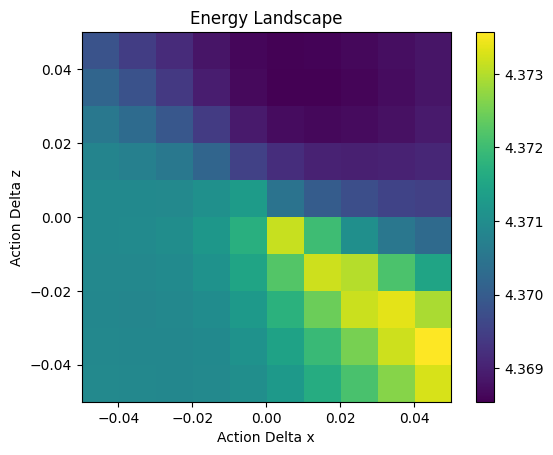

In [14]:
# Plot the energy
plot_data = []
for b, v in enumerate(loss):
    # TODO: why are we summing here?
    plot_data.append((
        a_hat[b, :-1, 0].detach().cpu().sum(),
        a_hat[b, :-1, 1].detach().cpu().sum(),
        a_hat[b, :-1, 2].detach().cpu().sum(),
        v,
    ))

delta_x = [d[0] for d in plot_data]
delta_y = [d[1] for d in plot_data]
delta_z = [d[2] for d in plot_data]
energy = [d[3] for d in plot_data]

gt_x = actions[0, T-2, 0]
gt_y = actions[0, T-2, 1]
gt_z = actions[0, T-2, 2]

# Create the 2D histogram
heatmap, xedges, yedges = np.histogram2d(delta_x, delta_z, weights=energy, bins=nsamples)

# Set axis labels
plt.xlabel("Action Delta x")
plt.ylabel("Action Delta z")
plt.title(f"Energy Landscape")

# Display the heatmap
print(f"Ground truth action (x,y,z) = ({gt_x:.5f},{gt_y:.5f},{gt_z:.5f})")
_ = plt.imshow(heatmap.T, origin="lower", extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis")
_ = plt.colorbar()

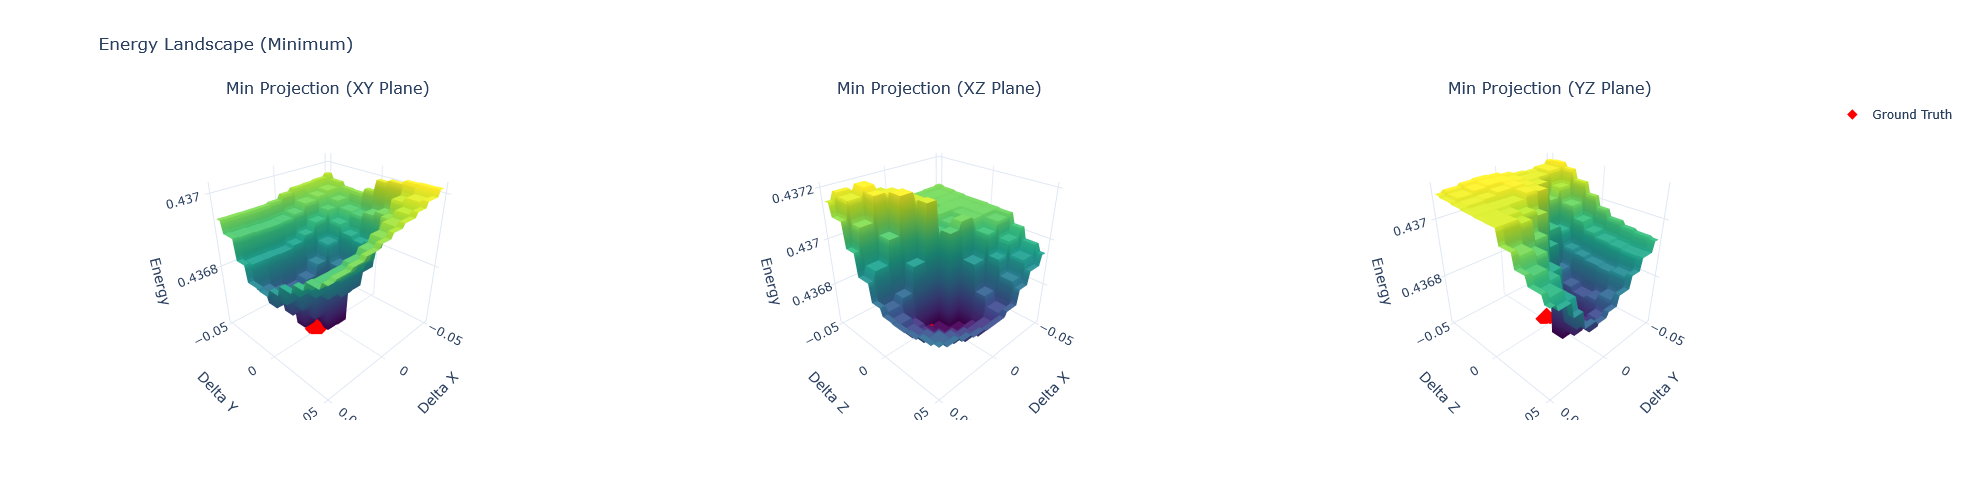

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata
#pio.renderers.default = "notebook

# Extract PyTorch tensors to CPU floats
delta_x = [d[0].detach().cpu().item() if hasattr(d[0], 'detach') else d[0] for d in plot_data]
delta_y = [d[1].detach().cpu().item() if hasattr(d[1], 'detach') else d[1] for d in plot_data]
delta_z = [d[2].detach().cpu().item() if hasattr(d[2], 'detach') else d[2] for d in plot_data]
energy  = [d[3].detach().cpu().item() if hasattr(d[3], 'detach') else d[3] for d in plot_data]

gt_x = actions[0, 0, 0].detach().cpu().item()
gt_y = actions[0, 0, 1].detach().cpu().item()
gt_z = actions[0, 0, 2].detach().cpu().item()

fig1 = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'scene'}, {'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=(
        "Min Projection (XY Plane)",
        "Min Projection (XZ Plane)",
        "Min Projection (YZ Plane)"
    )
)

plane_pairs = [
    (delta_x, delta_y, "Delta X", "Delta Y", gt_x, gt_y, 1),
    (delta_x, delta_z, "Delta X", "Delta Z", gt_x, gt_z, 2),
    (delta_y, delta_z, "Delta Y", "Delta Z", gt_y, gt_z, 3),
]

min_e = float(np.min(energy))

for d1, d2, lbl1, lbl2, gt1, gt2, col in plane_pairs:
    # 1. Binned minimum aggregation
    stat, x_edges, y_edges, _ = binned_statistic_2d(d1, d2, energy, statistic='min', bins=50)
    
    # Bin centers
    xc = (x_edges[:-1] + x_edges[1:]) / 2
    yc = (y_edges[:-1] + y_edges[1:]) / 2
    XC, YC = np.meshgrid(xc, yc)
    
    # Clean grid for smooth surface
    xi = np.linspace(min(d1), max(d1), 50)
    yi = np.linspace(min(d2), max(d2), 50)
    XI, YI = np.meshgrid(xi, yi)
    
    # Fill empty bins using nearest neighbor
    valid = ~np.isnan(stat)
    ZI = griddata((XC[valid], YC[valid]), stat[valid], (XI, YI), method='nearest')
    
    # 2. Add surface
    fig1.add_trace(
        go.Surface(
            x=xi, y=yi, z=ZI.T,
            colorscale='Viridis',
            showscale=False,
            hovertemplate=f"{lbl1}: %{{x:.2f}}<br>{lbl2}: %{{y:.2f}}<br>Min Energy: %{{z:.2f}}<extra></extra>"
        ),
        row=1, col=col
    )
    
    # Add Ground Truth marker
    fig1.add_trace(
        go.Scatter3d(
            x=[gt1], y=[gt2], z=[min_e],
            mode='markers',
            marker=dict(size=8, color='red', symbol='diamond'),
            name='Ground Truth',
            showlegend=(col == 1)
        ),
        row=1, col=col
    )

scenes = ['scene', 'scene2', 'scene3']
axis_labels = [
    ("Delta X", "Delta Y", "Energy"),
    ("Delta X", "Delta Z", "Energy"),
    ("Delta Y", "Delta Z", "Energy")
]

for scene_name, (x_lbl, y_lbl, z_lbl) in zip(scenes, axis_labels):
    fig1.update_layout({
        scene_name: dict(
            xaxis_title=x_lbl, yaxis_title=y_lbl, zaxis_title=z_lbl,
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
        )
    })

fig1.update_layout(
    height=500, width=1300,
    title_text="Energy Landscape (Minimum)",
    template="plotly_white"
)
fig1.show()

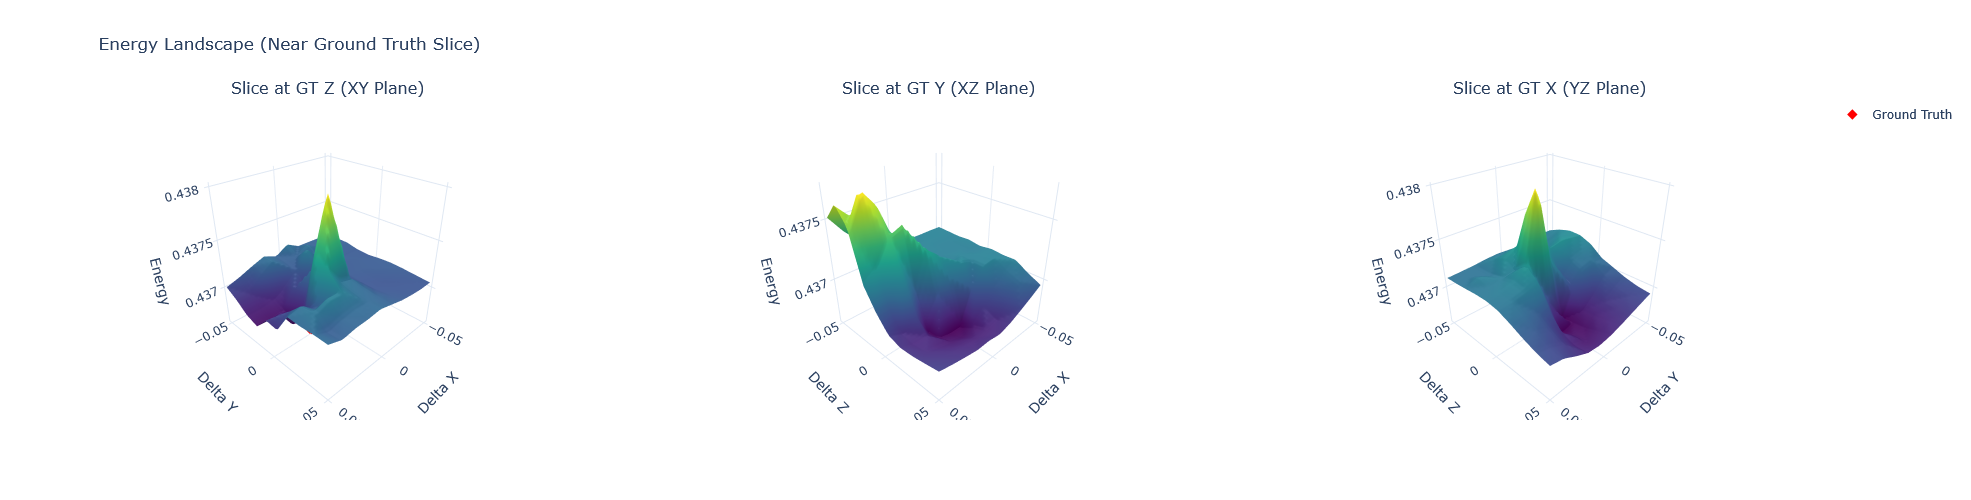

In [16]:
fig2 = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'scene'}, {'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=(
        "Slice at GT Z (XY Plane)",
        "Slice at GT Y (XZ Plane)",
        "Slice at GT X (YZ Plane)"
    )
)

# Convert to arrays for boolean indexing
dx_arr = np.array(delta_x)
dy_arr = np.array(delta_y)
dz_arr = np.array(delta_z)
e_arr  = np.array(energy)

# Slice configurations: (d1, d2, slice_axis_data, gt_slice_val, labels, gt1, gt2, col)
# Tolerance defines the thickness of the slice band
slices = [
    (dx_arr, dy_arr, dz_arr, gt_z, "Delta X", "Delta Y", gt_x, gt_y, 1),
    (dx_arr, dz_arr, dy_arr, gt_y, "Delta X", "Delta Z", gt_x, gt_z, 2),
    (dy_arr, dz_arr, dx_arr, gt_x, "Delta Y", "Delta Z", gt_y, gt_z, 3),
]

for d1, d2, slice_data, gt_val, lbl1, lbl2, gt1, gt2, col in slices:
    # Filter points within a band near ground truth (20% of range as band width)
    band_width = (np.max(slice_data) - np.min(slice_data)) * 0.20
    mask = np.abs(slice_data - gt_val) <= (band_width / 2.0)
    
    # Fallback to all data if slice contains too few points
    if np.sum(mask) < 10:
        mask = np.ones_like(slice_data, dtype=bool)

    d1_sub, d2_sub, e_sub = d1[mask], d2[mask], e_arr[mask]
    
    # Grid interpolation on slice subset
    xi = np.linspace(np.min(d1), np.max(d1), 40)
    yi = np.linspace(np.min(d2), np.max(d2), 40)
    XI, YI = np.meshgrid(xi, yi)
    
    ZI = griddata((d1_sub, d2_sub), e_sub, (XI, YI), method='linear')
    
    # Fill border NaNs
    nan_mask = np.isnan(ZI)
    if np.any(nan_mask):
        ZI_nearest = griddata((d1_sub, d2_sub), e_sub, (XI, YI), method='nearest')
        ZI[nan_mask] = ZI_nearest[nan_mask]

    # Surface plot
    fig2.add_trace(
        go.Surface(
            x=xi, y=yi, z=ZI,
            colorscale='Viridis',
            showscale=False,
            hovertemplate=f"{lbl1}: %{{x:.2f}}<br>{lbl2}: %{{y:.2f}}<br>Energy: %{{z:.2f}}<extra></extra>"
        ),
        row=1, col=col
    )
    
    # Ground Truth Marker
    fig2.add_trace(
        go.Scatter3d(
            x=[gt1], y=[gt2], z=[np.min(e_sub)],
            mode='markers',
            marker=dict(size=8, color='red', symbol='diamond'),
            name='Ground Truth',
            showlegend=(col == 1)
        ),
        row=1, col=col
    )

for scene_name, (x_lbl, y_lbl, z_lbl) in zip(scenes, axis_labels):
    fig2.update_layout({
        scene_name: dict(
            xaxis_title=x_lbl, yaxis_title=y_lbl, zaxis_title=z_lbl,
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
        )
    })

fig2.update_layout(
    height=500, width=1300,
    title_text="Energy Landscape (Near Ground Truth Slice)",
    template="plotly_white"
)
fig2.show()

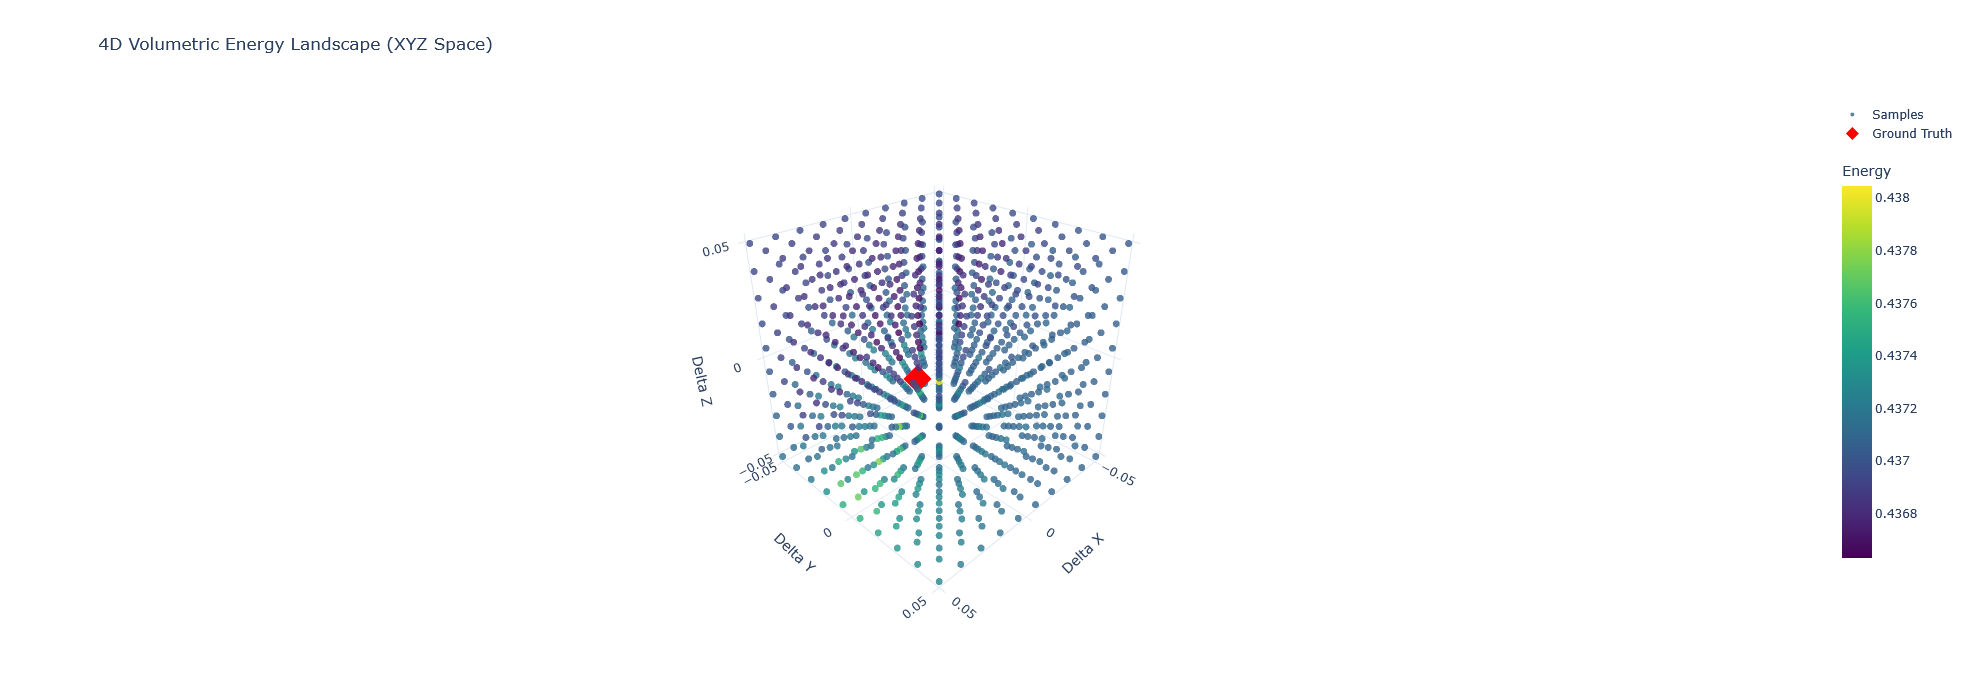

In [17]:
fig3 = go.Figure()

# Add 3D Scatter for all samples
fig3.add_trace(
    go.Scatter3d(
        x=delta_x, y=delta_y, z=delta_z,
        mode='markers',
        marker=dict(
            size=4,
            color=energy,
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title="Energy", len=0.8)
        ),
        hovertemplate="ΔX: %{x:.2f}<br>ΔY: %{y:.2f}<br>ΔZ: %{z:.2f}<br>Energy: %{marker.color:.4f}<extra></extra>",
        name="Samples"
    )
)

# Add Ground Truth marker
fig3.add_trace(
    go.Scatter3d(
        x=[gt_x], y=[gt_y], z=[gt_z],
        mode='markers',
        marker=dict(size=10, color='red', symbol='diamond'),
        name='Ground Truth'
    )
)

fig3.update_layout(
    scene=dict(
        xaxis_title="Delta X",
        yaxis_title="Delta Y",
        zaxis_title="Delta Z",
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
    ),
    height=700, width=900,
    title_text="4D Volumetric Energy Landscape (XYZ Space)",
    template="plotly_white"
)

fig3.show()